<a href="https://colab.research.google.com/github/evelynkleinenf-cloud/titanic_eda/blob/main/titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Introdução

## Contexto
O naufrágio do RMS Titanic, ocorrido em 1912, é um dos desastres marítimos mais conhecidos da história. Durante sua viagem inaugural, o navio colidiu com um iceberg no Oceano Atlântico Norte e acabou afundando, resultando na morte de grande parte dos passageiros e tripulantes a bordo.

Um dos fatores que agravou a tragédia foi o número insuficiente de botes salva-vidas, que não era suficiente para todos os passageiros. Como consequência, nem todos tiveram as mesmas chances de sobrevivência.

Com o passar do tempo, os dados desse evento passaram a ser amplamente utilizados em estudos de ciência de dados e aprendizado de máquina, permitindo investigar quais fatores podem ter influenciado as chances de sobrevivência.

## Objetivo
O objetivo deste projeto é identificar e analisar os principais fatores que influenciaram a sobrevivência dos passageiros do Titanic.

Para isso, será realizada uma Análise Exploratória de Dados (EDA) utilizando o conjunto de dados do Titanic. A análise busca compreender melhor o perfil dos passageiros e investigar quais características podem ter impactado suas chances de sobrevivência.

Ao longo do notebook, serão exploradas variáveis como sexo, idade, classe do passageiro, entre outras, com o objetivo de identificar possíveis padrões e relações entre essas características e a sobrevivência durante o desastre.

# 2.Bibliotecas

As bibliotecas necessárias neste projeto são importadas para permitir a manipulação, análise e visualização dos dados.

Pandas será utilizado para trabalhar com o dataset, NumPy para operações numéricas e Matplotlib e Seaborn para a criação de gráficos e visualizações durante a Análise Exploratória.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3.DataSet

## Importação do DataSet

Através do link disponibilizado pelo curso, é feito o upload do Banco de Dados para o GitHub, organizando em uma pasta e o acessando através de seu caminho.

In [29]:
url = "https://raw.githubusercontent.com/evelynkleinenf-cloud/titanic_eda/main/titanic_dataset.csv"
df_original = pd.read_csv(url)
df = df_original.copy()
print("DataSet Titanic carregado com sucesso")

DataSet Titanic carregado com sucesso


## Descrição do dataset

O conjunto de dados do Titanic contém informações sobre os passageiros que estavam a bordo do navio durante sua viagem inaugural em 1912.

Cada linha do DataSet representa um passageiro, e cada coluna contém uma característica associada a ele, como idade, sexo, classe da passagem e porto de embarque.

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Entendimento dos dados


Antes de iniciar a Análise Exploratória, é importante compreender a estrutura do banco de dados.

A função df.shape identifica a quantidade de linhas e colunas, permitindo entender o tamanho do conjunto de dados.

Com a função df.info obtemos informações sobre os tipos de dados de cada variável, além de indicar a presença de valores nulos.

Por fim, a função df.describe apresenta um resumo estatístico das variáveis numéricas, incluindo medidas como média, desvio padrão, valores mínimos e máximos.

Essas informações nos permitem uma visão inicial do DataSet e servem como base para as próximas etapas da Análise Exploratória.

In [31]:
df.shape

(891, 12)

O banco de dados possui 891 linhas e 12 colunas, indicando que há informações sobre 891 passageiros e 12 variáveis associadas a cada um deles.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Visualizamos os tipos de dados de cada coluna e a quantidade de valores não nulos. Observa-se que algumas variáveis possuem valores ausentes, como Age, Cabin e Embarked.

Esses valores faltantes deverão ser considerados nas etapas seguintes da Análise, exigindo tratamento e limpeza dos dados.

Também é possível observar que o DataSet possui variáveis numéricas e categóricas, o que permitirá diferentes tipos de análises e visualizações.

In [33]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Obtemos informações como média, desvio padrão, valores mínimos e máximos.

A partir dessas estatísticas, é possível observar características importantes do banco de dados, como a distribuição das idades dos passageiros, o valor das passagens e outras métricas que ajudam a compreender melhor o perfil dos indivíduos presentes no DataSet.

### Descrição das variáveis.

O banco de dados do Titanic contém informações sobre os passageiros que estavam a bordo do navio.

Cada variável representa uma característica associada aos passageiros. São elas:

**PassengerId:** Identificador único atribuído a cada passageiro no DataSet.

**Survived:** Indica se o passageiro sobreviveu ao naufrágio.

0 = Não sobreviveu

1 = Sobreviveu

**Pclass:** Classe da passagem do passageiro, que também pode representar o nível socioeconômico.

1 = Primeira classe

2 = Segunda classe

3 = Terceira classe

**Name:** Nome completo do passageiro.

**Sex:** Sexo do passageiro (masculino ou feminino).

**Age:** Idade do passageiro em anos.

**SibSp:** Número de irmãos ou cônjuges do passageiro que estavam a bordo do Titanic.

**Parch:** Número de pais ou filhos do passageiro que estavam a bordo.

**Ticket:** Número do ticket da passagem.

**Fare:** Valor pago pela passagem do navio.

**Cabin:** Número da cabine onde o passageiro estava acomodado.

**Embarked:** Porto onde o passageiro embarcou no Titanic.

C = Cherbourg (França)

Q = Queenstown (Irlanda)

S = Southampton (Inglaterra)

Após visualizar e compreender cada variável do DataSet, é possível identificar quais são relevantes para a análise proposta.


Assim, selecionamos apenas as colunas consideradas mais importantes para investigar os fatores que podem ter influenciado a sobrevivência dos passageiros do Titanic.

Essa seleção permite simplificar o banco de dados e concentrar a análise em variáveis com maior potencial explicativo, como classe do passageiro, sexo, idade, número de familiares a bordo, valor da passagem e porto de embarque.

Desta forma, o DataSet passa a conter apenas as informações mais relevantes para as etapas seguintes de Tratamento dos Dados e Análise Exploratória.

In [34]:
df_principais = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
df_principais.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# 4.Limpeza e Tratamento dos Dados

Agora, devemos identificar e corrigir possíveis problemas no conjunto de dados, como valores ausentes, registros duplicados, tipos de dados inadequados e inconsistências nas variáveis.

Desta maneira, evitamos o comprometimento da qualidade da Análise e obtemos interpretações corretas dos resultados.

Ou seja, garantimos que os dados estejam mais confiáveis e adequados para as próximas etapas.

## Tratamento de Duplicados

Linhas duplicadas podem distorcer a Análise e gerar interpretações incorretas, pois representam a repetição de um mesmo registro.

Por essa razão, precisamos identificá-las e eliminá-las.

In [35]:
num_duplicadas = df_principais.duplicated().sum()
print(f"Número de linhas duplicadas no DataFrame df_principais: {num_duplicadas}")

Número de linhas duplicadas no DataFrame df_principais: 111


In [36]:
print(f"Linhas antes da remoção de duplicadas: {df_principais.shape[0]}")
df_principais_sem_duplicadas = df_principais.drop_duplicates().copy()
print(f"Linhas depois da remoção de duplicadas: {df_principais_sem_duplicadas.shape[0]}")

Linhas antes da remoção de duplicadas: 891
Linhas depois da remoção de duplicadas: 780


O número de linhas no DataFrame foi reduzido de 891 para 780, garantindo que cada observação seja única e melhorando a integridade dos dados para análises futuras.

## Tratamento de Valores Nulos

Valores ausentes podem prejudicar a Análise, pois algumas técnicas estatísticas e visualizações dependem de informações completas.

Primeiro, identificamos estes casos e, após, decidimos qual a melhor estratégia para tratar esses valores.

In [37]:
print('Valores nulos por coluna antes do tratamento(contagem):')
print(df_principais_sem_duplicadas.isnull().sum())
print('Valores nulos por coluna antes do tratamento(porcentagem):')
print(df_principais_sem_duplicadas.isnull().sum() / len(df_principais_sem_duplicadas) * 100)

Valores nulos por coluna antes do tratamento(contagem):
Survived      0
Pclass        0
Sex           0
Age         104
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Valores nulos por coluna antes do tratamento(porcentagem):
Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         13.333333
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Embarked     0.256410
dtype: float64


Algumas variáveis possuem valores ausentes, principalmente na coluna Age, que contém registros sem informação de idade. A coluna Embarked também apresenta uma pequena quantidade de valores nulos.

Para evitar a perda de muitos dados, os valores numéricos ausentes da coluna Age podem ser substituídos pela mediana, e os valores faltantes em Embarked podem ser preenchidos pela moda, por ser uma variável categórica.

In [38]:
# Tratar a coluna 'Age' com a mediana
median_age = df_principais_sem_duplicadas['Age'].median()
df_principais_sem_duplicadas['Age'] = df_principais_sem_duplicadas['Age'].fillna(median_age)
print("Valores nulos em 'Age' preenchidos com a mediana:", median_age)

Valores nulos em 'Age' preenchidos com a mediana: 28.0


In [39]:
# Tratar a coluna 'Embarked' com a moda
mode_embarked = df_principais_sem_duplicadas['Embarked'].mode()[0]
df_principais_sem_duplicadas['Embarked'] = df_principais_sem_duplicadas['Embarked'].fillna(mode_embarked)
print("Valores nulos em 'Embarked' preenchidos com a moda:", mode_embarked)

Valores nulos em 'Embarked' preenchidos com a moda: S


In [40]:
# Verificar se tratamos todos os valores nulos
print("Valores nulos após o tratamento:\n",df_principais_sem_duplicadas.isnull().sum())

Valores nulos após o tratamento:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## Tratamento de Tipagem de Dados

Verificamos os tipos de dados das variáveis presentes no DataSet e garantimos que cada coluna esteja com o tipo de dado adequado para facilitar as análises, além de melhorar a organização e eficiência no processamento dos dados.

In [41]:
print("Informações sobre o DataSet antes do ajuste de tipagem:")
df_principais_sem_duplicadas.dtypes

Informações sobre o DataSet antes do ajuste de tipagem:


,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


As variáveis Survived, Pclass, Sex e Embarked representam categorias e podem ser convertidas para o tipo category.

In [42]:
df_principais_sem_duplicadas['Survived'] = df_principais_sem_duplicadas['Survived'].astype('category')
df_principais_sem_duplicadas['Pclass'] = df_principais_sem_duplicadas['Pclass'].astype('category')
df_principais_sem_duplicadas['Sex'] = df_principais_sem_duplicadas['Sex'].astype('category')
df_principais_sem_duplicadas['Embarked'] = df_principais_sem_duplicadas['Embarked'].astype('category')
print("DataFrame com tipagem atualizada:")
df_principais_sem_duplicadas.dtypes

DataFrame com tipagem atualizada:


,0
Survived,category
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category


Após a conversão, as variáveis categóricas passam a utilizar o tipo category, o que melhora a organização dos dados e facilita as análises e visualizações durante a etapa de Análise Exploratória.

## Valores Inconsistentes

Um valor inconsistente pode ocorrer quando há erros de registro, categorias escritas de formas diferentes ou valores inesperados em determinadas variáveis.

Para identificar possíveis inconsistências, analisamos os valores únicos de algumas variáveis categóricas e também os intervalos de valores das variáveis numéricas.

In [43]:
df_principais_sem_duplicadas['Survived'].value_counts(dropna=False)

,count
Survived,
0,458
1,322


In [44]:
df_principais_sem_duplicadas['Pclass'].value_counts(dropna=False)

,count
Pclass,
3,404
1,212
2,164


In [45]:
df_principais_sem_duplicadas['Sex'].value_counts(dropna=False)

,count
Sex,
male,488
female,292


In [46]:
df_principais_sem_duplicadas['Embarked'].value_counts(dropna=False)

,count
Embarked,
S,567
C,155
Q,58


Verificamos se as categorias estão padronizadas e consistentes. As variáveis apresentam apenas os valores esperados, sem variações de escrita ou categorias inesperadas. Isso indica que não há inconsistências nessas variáveis categóricas.

In [47]:
df_principais_sem_duplicadas[['Age','SibSp','Parch','Fare']].describe()

,Age,SibSp,Parch,Fare
count,780.000000,780.000000,780.000000,780.000000
mean,29.571051,0.525641,0.417949,34.829108
std,13.722689,0.988046,0.838536,52.263440
min,0.420000,0.000000,0.000000,0.000000
25%,21.750000,0.000000,0.000000,8.050000
50%,28.000000,0.000000,0.000000,15.950000
75%,36.000000,1.000000,1.000000,34.375000
max,80.000000,8.000000,6.000000,512.329200


Nas variáveis numéricas verificamos se existem valores fora do intervalo esperado, como idades negativas ou valores extremamente altos que possam indicar erros de registro.

Observamos que os valores destas variáveis estão dentro do esperado, indicando que não há inconsistências.

## Feature Engineering

Nesta etapa, criamos e transformamos variáveis a partir das informações do DataSet.

Deste modo, são geradas novas características que facilitam a Análise e mostram padrões relevantes relacionados à sobrevivência dos passageiros.

### Variável Tamanho da Família

Uma informação relevante é o tamanho da família do passageiro a bordo do Titanic. Essa informação pode ser obtida a partir das variáveis SibSp (número de irmãos/cônjuges) e Parch (número de pais/filhos).

A nova variável TamanhoFamilia será criada somando essas duas variáveis e adicionando o próprio passageiro.

In [48]:
df_principais_sem_duplicadas["TamanhoFamilia"] = df_principais_sem_duplicadas["SibSp"] + df_principais_sem_duplicadas["Parch"] + 1
df_principais_sem_duplicadas[['SibSp','Parch','TamanhoFamilia']].head()

,SibSp,Parch,TamanhoFamilia
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


A variável TamanhoFamilia representa o número total de membros da família do passageiro presentes no navio. Com ela, podemos analisar se passageiros que viajavam sozinhos ou acompanhados tiveram as mesmas chances de sobrevivência.

### Variável Passageiro Sozinho

Com base no tamanho da família, identificamos se o passageiro estava viajando sozinho ou acompanhado. Para isso, criamos a variável PassSozinho, que indicará se o passageiro estava sozinho no navio.

In [49]:
df_principais_sem_duplicadas['PassSozinho'] = (df_principais_sem_duplicadas['TamanhoFamilia'] == 1).astype(int)
df_principais_sem_duplicadas[['TamanhoFamilia','PassSozinho']].head()

,TamanhoFamilia,PassSozinho
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


O valor 1 representa passageiros que estavam sozinhos e 0 indica que o passageiro estava com familiares.

Assim como a variável TamanhoFamilia, com a variável PassSozinho podemos analisar se passageiros que viajavam sozinhos ou acompanhados tiveram as mesmas chances de sobrevivência.

### Grupos de Categoria de Família

Seguindo a mesma lógica das variáveis Tamanho da Família e Passageiro Sozinho, criamos também a variável Categoria de Família, onde agrupamos os passageiros em: Sozinho  (passageiro sem familiares a bordo do navio), Família pequena (até 4 familiares a bordo) e Família grande (mais de 4 familiares a bordo).

In [50]:
bins = [0,1,4,10]
labels = ['Sozinho','Familia pequena','Familia grande']
df_principais_sem_duplicadas['CategoriaFamilia'] = pd.cut(df_principais_sem_duplicadas['TamanhoFamilia'], bins=bins, labels=labels)
df_principais_sem_duplicadas.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TamanhoFamilia,PassSozinho,CategoriaFamilia
0,0,3,male,22.0,1,0,7.2500,S,2,0,Familia pequena
1,1,1,female,38.0,1,0,71.2833,C,2,0,Familia pequena
2,1,3,female,26.0,0,0,7.9250,S,1,1,Sozinho
3,1,1,female,35.0,1,0,53.1000,S,2,0,Familia pequena
4,0,3,male,35.0,0,0,8.0500,S,1,1,Sozinho


### Grupos de Faixas Etárias


Para facilitar a análise da variável Age, as idades podem ser agrupadas em faixas etárias, permitindo analisar de forma mais clara como a idade pode ter influenciado as chances de sobrevivência.

In [51]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Crianca','Adolescente','JovemAdulto','Adulto','Idoso']
df_principais_sem_duplicadas['FaixaEtaria'] = pd.cut(df_principais_sem_duplicadas['Age'], bins=bins, labels=labels, include_lowest=True)
df_principais_sem_duplicadas[['Age','FaixaEtaria']].head()

,Age,FaixaEtaria
0,22.0,JovemAdulto
1,38.0,Adulto
2,26.0,JovemAdulto
3,35.0,JovemAdulto
4,35.0,JovemAdulto


A nova variável FaixaEtaria classifica os passageiros nas seguintes faixas etárias: Criança (0 a 12 anos), Adolescente (13 a 18 anos), Jovem Adulto (19 a 35 anos), Adulto (36 a 60 anos), Idoso (61 a 100 anos).


### DataFrame Atualizado

Após a Limpeza, Tratamento dos Dados, e do Feature Engineering, vamos verificar se todas as alterações estão corretas no novo DataSet e visualizá-lo.

In [52]:
df_principais_sem_duplicadas.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TamanhoFamilia,PassSozinho,CategoriaFamilia,FaixaEtaria
0,0,3,male,22.0,1,0,7.2500,S,2,0,Familia pequena,JovemAdulto
1,1,1,female,38.0,1,0,71.2833,C,2,0,Familia pequena,Adulto
2,1,3,female,26.0,0,0,7.9250,S,1,1,Sozinho,JovemAdulto
3,1,1,female,35.0,1,0,53.1000,S,2,0,Familia pequena,JovemAdulto
4,0,3,male,35.0,0,0,8.0500,S,1,1,Sozinho,JovemAdulto


In [53]:
df_principais_sem_duplicadas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Survived          780 non-null    category
 1   Pclass            780 non-null    category
 2   Sex               780 non-null    category
 3   Age               780 non-null    float64 
 4   SibSp             780 non-null    int64   
 5   Parch             780 non-null    int64   
 6   Fare              780 non-null    float64 
 7   Embarked          780 non-null    category
 8   TamanhoFamilia    780 non-null    int64   
 9   PassSozinho       780 non-null    int64   
 10  CategoriaFamilia  778 non-null    category
 11  FaixaEtaria       780 non-null    category
dtypes: category(6), float64(2), int64(4)
memory usage: 48.1 KB


In [54]:
df_principais_sem_duplicadas.describe()

,Age,SibSp,Parch,Fare,TamanhoFamilia,PassSozinho
count,780.000000,780.000000,780.000000,780.000000,780.00000,780.000000
mean,29.571051,0.525641,0.417949,34.829108,1.94359,0.566667
std,13.722689,0.988046,0.838536,52.263440,1.51988,0.495854
min,0.420000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,21.750000,0.000000,0.000000,8.050000,1.00000,0.000000
50%,28.000000,0.000000,0.000000,15.950000,1.00000,1.000000
75%,36.000000,1.000000,1.000000,34.375000,2.00000,1.000000
max,80.000000,8.000000,6.000000,512.329200,11.00000,1.000000


In [55]:
df_titanic = df_principais_sem_duplicadas.copy()
df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TamanhoFamilia,PassSozinho,CategoriaFamilia,FaixaEtaria
0,0,3,male,22.0,1,0,7.2500,S,2,0,Familia pequena,JovemAdulto
1,1,1,female,38.0,1,0,71.2833,C,2,0,Familia pequena,Adulto
2,1,3,female,26.0,0,0,7.9250,S,1,1,Sozinho,JovemAdulto
3,1,1,female,35.0,1,0,53.1000,S,2,0,Familia pequena,JovemAdulto
4,0,3,male,35.0,0,0,8.0500,S,1,1,Sozinho,JovemAdulto


Após confirmar que todas as alterações no DataSet foram realizadas com sucesso, criamos um novo DataFrame para otimizar a organização e análise do mesmo.

# 5.Análise Estatística

Após a Análise Exploratória dos Dados e a visualização das Relações entre as Variáveis, é útil realizar uma análise estatística para obter uma compreensão mais detalhada das características do conjunto de dados.

Nesta etapa, serão analisadas medidas estatísticas descritivas, como média, mediana, desvio padrão e distribuição dos dados. Essas métricas ajudam a resumir as principais características das variáveis e a identificar possíveis padrões ou diferenças entre grupos de passageiros.

## Estatísticas Descritivas das Variáveis Numéricas

Inicialmente, serão analisadas as estatísticas descritivas das variáveis numéricas do dataset. Essas medidas incluem informações como média, mediana, desvio padrão, valores mínimos e máximos, que ajudam a compreender melhor a distribuição dos dados.

In [56]:
df_titanic[['Survived','Age','SibSp','Parch','Fare','TamanhoFamilia','PassSozinho']].describe()

,Age,SibSp,Parch,Fare,TamanhoFamilia,PassSozinho
count,780.000000,780.000000,780.000000,780.000000,780.00000,780.000000
mean,29.571051,0.525641,0.417949,34.829108,1.94359,0.566667
std,13.722689,0.988046,0.838536,52.263440,1.51988,0.495854
min,0.420000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,21.750000,0.000000,0.000000,8.050000,1.00000,0.000000
50%,28.000000,0.000000,0.000000,15.950000,1.00000,1.000000
75%,36.000000,1.000000,1.000000,34.375000,2.00000,1.000000
max,80.000000,8.000000,6.000000,512.329200,11.00000,1.000000


As estatísticas descritivas permitem observar a distribuição geral das variáveis numéricas. É possível identificar a média das idades dos passageiros, a variação nos valores das passagens e a quantidade média de familiares a bordo.

Essas informações ajudam a compreender melhor o perfil geral dos passageiros presentes no dataset.

## Comparação Estatística entre Sobreviventes e Não Sobreviventes

Para entender melhor as diferenças entre os passageiros que sobreviveram e aqueles que não sobreviveram, serão comparadas algumas estatísticas descritivas separadas pela variável de sobrevivência.

Essa análise permite identificar se existem diferenças significativas em variáveis como idade, valor da passagem e tamanho da família entre os dois grupos.

In [57]:
# Comparando as médias
df_titanic.groupby('Survived')[['Age','SibSp','Parch','Fare','TamanhoFamilia','PassSozinho']].mean()

/tmp/ipykernel_113515/2757789449.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_titanic.groupby('Survived')[['Age','SibSp','Parch','Fare','TamanhoFamilia','PassSozinho']].mean()


,Age,SibSp,Parch,Fare,TamanhoFamilia,PassSozinho
Survived,,,,,,
0,30.466157,0.556769,0.368996,24.026482,1.925764,0.639738
1,28.297888,0.481366,0.487578,50.194333,1.968944,0.462733


Em alguns casos, passageiros que sobreviveram podem apresentar valores médios mais altos em determinadas variáveis, como o preço da passagem, o que pode refletir diferenças relacionadas à classe social.

## Distribuição das Variáveis Numéricas

Além das estatísticas descritivas, também é útil visualizar a distribuição das variáveis numéricas. Isso permite identificar características como assimetria, concentração de valores e presença de possíveis outliers.

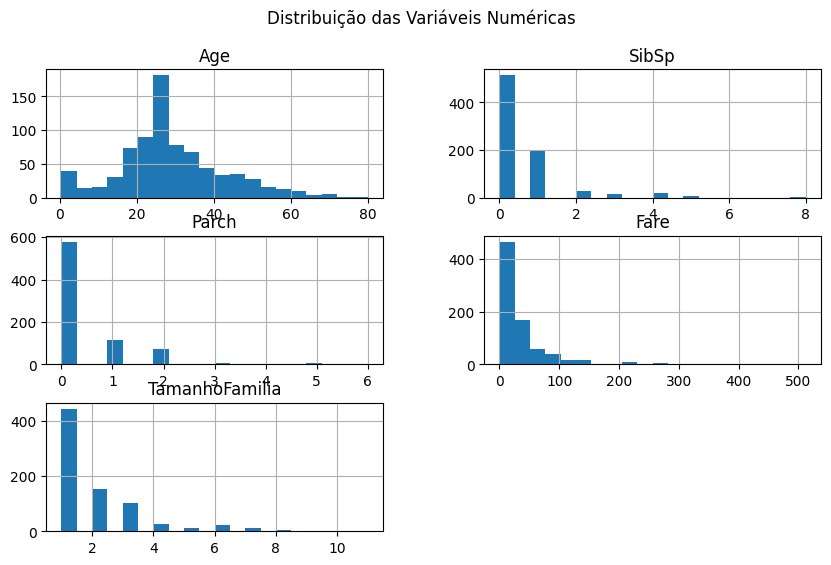

In [58]:
df_titanic[['Age','SibSp','Parch','Fare','TamanhoFamilia']].hist(figsize=(10,6), bins=20)
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.show()

- **Idade (Age):** A distribuição apresenta maior concentração entre aproximadamente 20 e 35 anos, indicando que a maioria dos passageiros era composta por adultos jovens. Também é possível observar alguns passageiros com idade mais elevada, chegando a cerca de 80 anos, porém em menor quantidade.

- **Número de irmãos ou cônjuges a bordo (SibSp):** A grande maioria dos passageiros viajava com 0 ou 1 irmão/cônjuge. Valores mais altos aparecem com baixa frequência, indicando que eram raros os casos de passageiros viajando com muitos familiares desse tipo.

- **Número de pais ou filhos a bordo (Parch):** A maior parte dos passageiros não estava acompanhada de pais ou filhos, concentrando-se no valor 0. Alguns poucos passageiros viajavam com 1 ou 2 familiares, enquanto valores maiores são bastante raros.

- **Tarifa paga (Fare):** A maioria dos passageiros pagou tarifas relativamente baixas, enquanto poucos pagaram valores muito elevados. Isso indica uma grande diferença entre os valores pagos, possivelmente relacionada às diferentes classes de acomodação do navio.

- **Tamanho da Família (TamanhoFamilia):** Representa o número total de familiares a bordo e mostra maior concentração em valores baixos, principalmente entre 1 e 3 pessoas. Isso indica que a maioria dos passageiros viajava sozinho ou com poucos familiares, enquanto famílias maiores eram menos comuns.


**Conclusão**


*   A maioria dos passageiros era adulto jovem.

*   Muitos passageiros viajavam sozinhos ou com poucos familiares.


*   O valor da tarifa apresenta grande variação, com poucos passageiros pagando valores muito altos.

Essas características ajudam a compreender melhor o perfil dos passageiros e servem como base para análises posteriores, como investigar quais fatores podem ter influenciado a sobrevivência no desastre do Titanic.

## Análise de Outliers



Outro aspecto importante da análise estatística é a identificação de outliers, que são valores extremamente altos ou baixos em relação ao restante dos dados. Esses valores podem influenciar medidas estatísticas e afetar algumas análises.

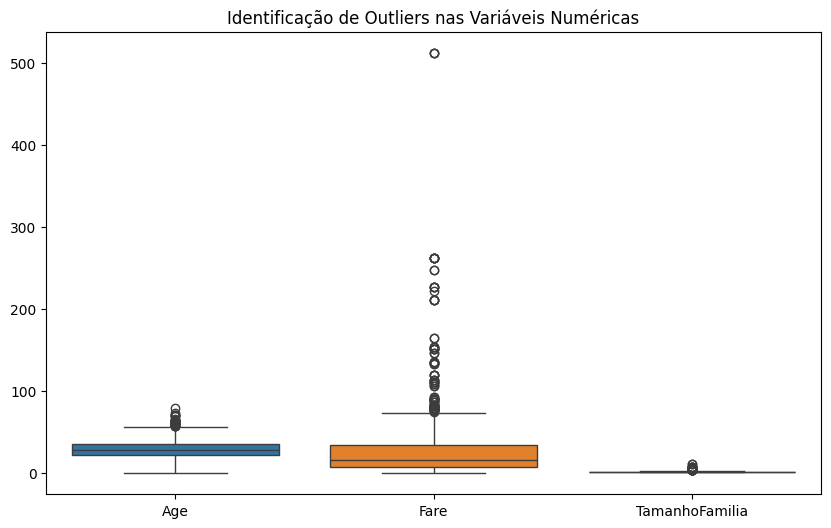

In [59]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_titanic[['Age','Fare','TamanhoFamilia']])
plt.title('Identificação de Outliers nas Variáveis Numéricas')
plt.show()

Observa-se que a variável Fare, por exemplo, apresenta alguns valores significativamente mais altos do que a maioria das passagens, indicando a presença de possíveis outliers.

A identificação desses valores ajuda a compreender melhor a dispersão dos dados e a interpretar corretamente os resultados da análise.

# 6.Análise exploratória (EDA)

Nesta seção, iremos explorar nosso DataFrame atualizado por meio de estatísticas descritivas e visualizações gráficas, permitindo identificar padrões, tendências e possíveis relações entre as variáveis.

Neste projeto, utilizaremos a Análise Exploratória para compreender melhor quais os fatores que podem ter influenciado a sobrevivência dos passageiros do Titanic.

## Sobrevivência Geral

Antes de analisar fatores específicos que podem ter influenciado a sobrevivência, é importante observar a distribuição geral da variável Survived, que indica se o passageiro sobreviveu (1) ou não sobreviveu (0) ao naufrágio do Titanic.

Assim, compreendemos qual foi a proporção geral de sobreviventes e não sobreviventes.

In [60]:
# Contagem de sobreviventes
df_titanic['Survived'].value_counts()

,count
Survived,
0,458
1,322


In [61]:
# Proporção de sobreviventes
df_titanic['Survived'].value_counts(normalize=True)*100

,proportion
Survived,
0,58.717949
1,41.282051


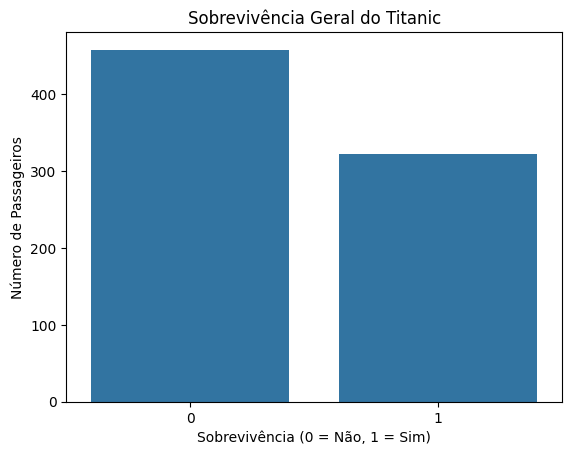

In [62]:
# Visualização gráfica da sobrevivência
sns.countplot(x='Survived', data=df_titanic)
plt.title('Sobrevivência Geral do Titanic')
plt.xlabel('Sobrevivência (0 = Não, 1 = Sim)')
plt.ylabel('Número de Passageiros')
plt.show()

A análise da variável Survived mostra que a maior parte dos passageiros não sobreviveu ao naufrágio do Titanic.

Esse resultado reforça a gravidade do desastre e destaca a importância de investigar quais fatores podem ter influenciado as chances de sobrevivência dos passageiros.

Essas relações serão exploradas nas próximas análises.

## Sobrevivência por Gênero

Um dos fatores que podem ter influenciado a sobrevivência dos passageiros do Titanic é o gênero.

Há relatos históricos indicando que houve uma prioridade para mulheres e crianças no acesso aos botes salva-vidas.

Dessa forma, analisar a relação entre gênero e sobrevivência pode ajudar a identificar se esse fator teve impacto significativo nas chances de sobrevivência dos passageiros.

In [63]:
# Contagem de sobreviventes por gênero
df_titanic.groupby('Sex', observed=True)['Survived'].value_counts().loc[:,1]

,count
Sex,
female,216
male,106


In [64]:
# Taxa de sobrevivência por gênero
df_titanic.groupby('Sex', observed=True)['Survived'].value_counts(normalize=True).loc[:,1] * 100

,proportion
Sex,
female,73.972603
male,21.721311


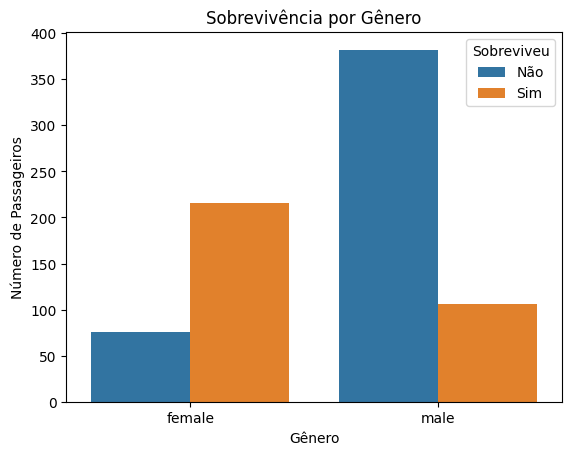

In [65]:
# Visualização gráfica
sns.countplot(x='Sex', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

Percebemos uma diferença significativa nas taxas de sobrevivência entre os gêneros, tendo as passageiras uma taxa de sobrevivência muito maior em comparação aos passageiros.

Esse padrão pode estar relacionado a forma como foi conduzida a evacuação do navio, que priorizavam mulheres e crianças no embarque nos botes salva-vidas.

Essa observação indica que o gênero foi um dos fatores mais relevantes para a sobrevivência no desastre do Titanic.

## Sobrevivência por Classe Social

No navio, os passageiros estavam divididos em primeira, segunda e terceira classe (exibida no DataFrame como a variável Pclass), o que refletia diferentes níveis socioeconômicos e também diferentes localizações dentro da embarcação. Este também pode ser outro fator que influenciou as chances de sobrevivência dos passageiros do Titanic.

In [66]:
# Quantas pessoas sobreviveram em cada classe
df_titanic.groupby('Pclass',observed=True)['Survived'].value_counts().loc[:,1]

,count
Pclass,
1,135
2,83
3,104


In [67]:
# Porcentagem de sobreviventes dentro de cada classe
df_titanic.groupby('Pclass', observed=True)['Survived'].value_counts(normalize=True).loc[:,1] * 100

,proportion
Pclass,
1,63.679245
2,50.609756
3,25.742574


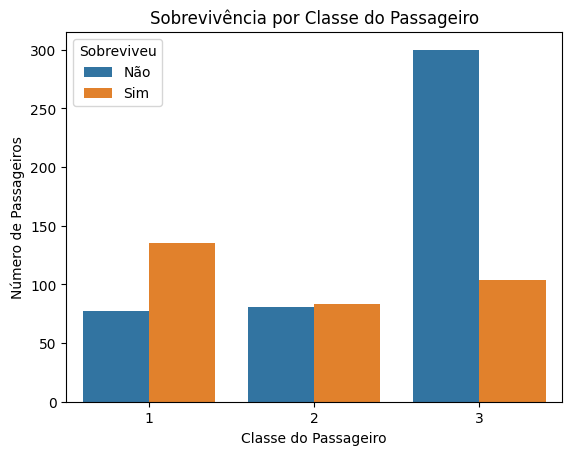

In [68]:
# Visualização gráfica
sns.countplot(x='Pclass', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Classe do Passageiro')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

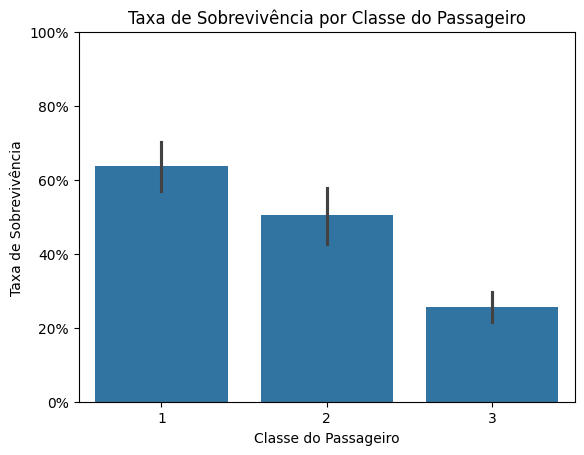

In [69]:
# Taxa de sobrevivência por classe
from matplotlib.ticker import PercentFormatter
sns.barplot(x='Pclass', y='Survived', data=df_titanic, order=[1,2,3])
plt.title('Taxa de Sobrevivência por Classe do Passageiro')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

Observa-se que a classe do passageiro teve um impacto significativo nas chances de sobrevivência. Passageiros da primeira classe apresentaram uma taxa de sobrevivência maior, enquanto passageiros da terceira classe tiveram as menores chances de sobreviver.

Esse resultado pode estar relacionado a diversos fatores, como a localização das cabines no navio, o acesso aos botes salva-vidas e as prioridades durante o resgate. Passageiros das classes mais altas possivelmente tiveram acesso mais rápido aos botes, enquanto passageiros das classes mais baixas enfrentaram maiores dificuldades durante a evacuação.

Assim, percebemos que a classe social foi um fator relevante na sobrevivência dos passageiros do Titanic.

## Sobrevivência por Idade

Durante situações de resgate, é comum que crianças recebam prioridade, o que pode ter impactado a taxa de sobrevivência entre diferentes faixas etárias.

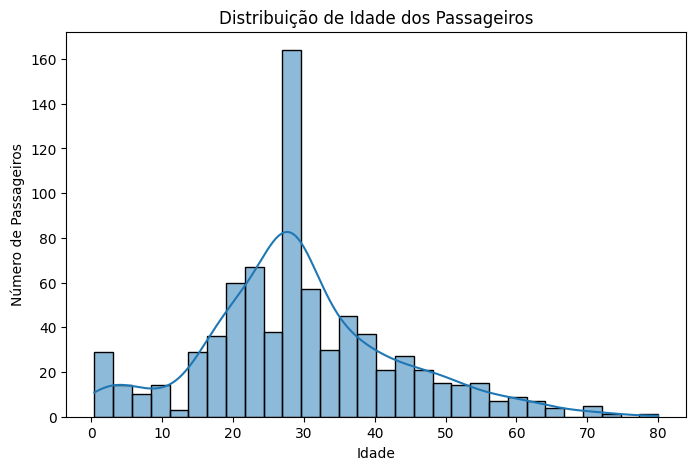

In [70]:
# Distribuição de idade dos passageiros
plt.figure(figsize=(8,5))
sns.histplot(data=df_titanic, x='Age', bins=30,kde=True)
plt.title('Distribuição de Idade dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Número de Passageiros')
plt.show()

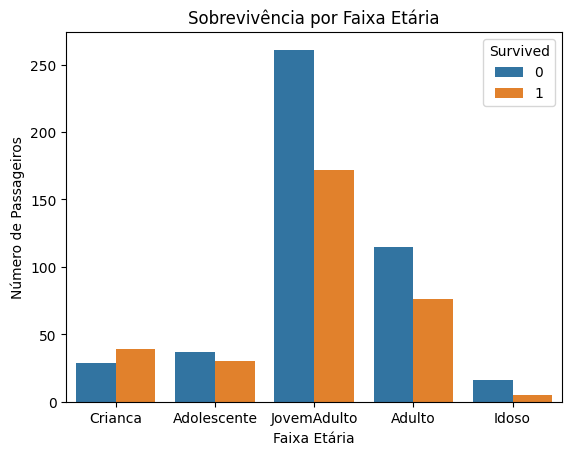

In [71]:
# Faixa etária e sobrevivência
sns.countplot(x='FaixaEtaria', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Passageiros')
plt.show()

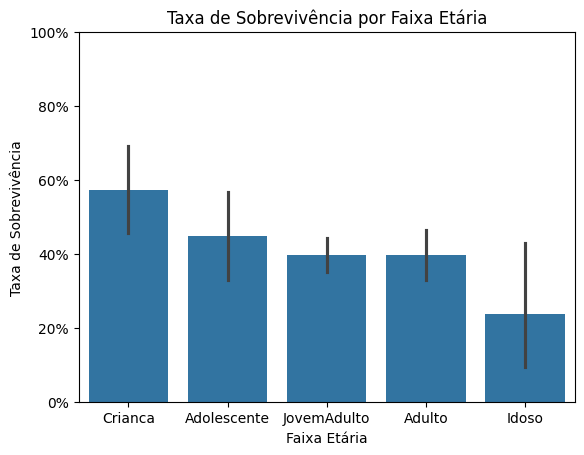

In [72]:
# Taxa de sobrevivência por faixa etária
from matplotlib.ticker import PercentFormatter
sns.barplot(x='FaixaEtaria', y='Survived', data=df_titanic)
plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

Os gráficos indicam que crianças apresentaram uma taxa de sobrevivência relativamente maior em comparação com adultos, o que pode estar relacionado à prioridade dada a mulheres e crianças durante o processo de evacuação.

Entretanto, também é possível observar que passageiros de diversas faixas etárias foram afetados pelo desastre, indicando que a idade, embora relevante, não foi o único fator determinante para a sobrevivência. Isso reforça a importância de considerar múltiplas variáveis para compreender a chance de sobrevivência no Titanic.

## Sobrevivência por Tamanho da Família vs Sozinhos

Passageiros que viajavam com familiares poderiam ter mais apoio durante situações de emergência, enquanto passageiros que viajavam sozinhos ou com muitos familiares poderiam enfrentar mais dificuldades.

In [73]:
# Taxa de sobrevivência em porcentagem para cada categoria de tamanho de família
df_titanic['Survived'] = df_titanic['Survived'].astype(int)
df_titanic.groupby('CategoriaFamilia', observed=True)['Survived'].mean() * 100

,Survived
CategoriaFamilia,
Sozinho,33.710407
Familia pequena,57.597173
Familia grande,18.867925


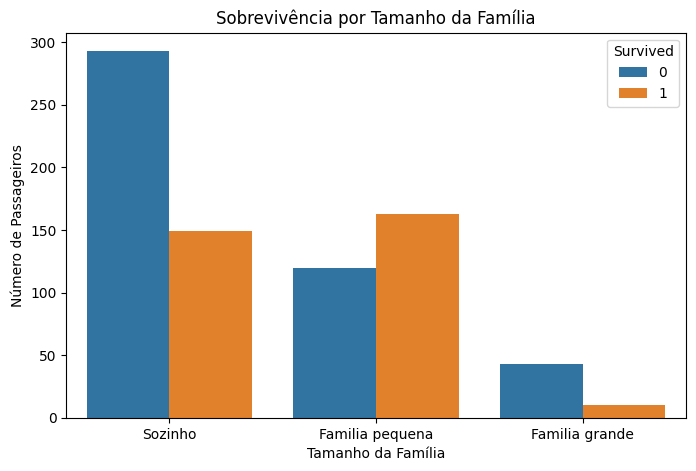

In [74]:
# Sobrevivência por tamanho da família
plt.figure(figsize=(8,5))
sns.countplot(x='CategoriaFamilia', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Tamanho da Família')
plt.xlabel('Tamanho da Família')
plt.ylabel('Número de Passageiros')
plt.show()

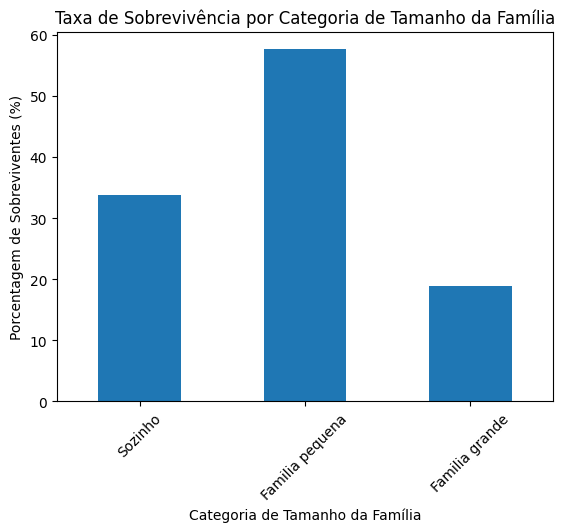

In [75]:
# Taxa de sobrevivência por Categoria de Família
taxa = df_titanic.groupby('CategoriaFamilia', observed=True)['Survived'].mean() * 100
taxa.plot(kind='bar')
plt.title('Taxa de Sobrevivência por Categoria de Tamanho da Família')
plt.xlabel('Categoria de Tamanho da Família')
plt.xticks(rotation=45)
plt.ylabel('Porcentagem de Sobreviventes (%)')
plt.show()

Passageiros que viajavam com famílias muito grandes ou completamente sozinhos apresentaram menores taxas de sobrevivência. Já passageiros que viajavam com famílias pequenas ou médias parecem ter tido chances maiores de sobreviver.

Esse resultado sugere que o tamanho da família pode ter tido alguma influência na sobrevivência, possivelmente devido ao apoio entre familiares e/ou à organização durante a evacuação.

Essa observação reforça a ideia de que características sociais e familiares também podem ter influenciado a sobrevivência no desastre do Titanic.

## Sobrevivência por Preço da Passagem

Em geral, passageiros que pagaram valores mais altos possivelmente estavam associados às classes mais altas do navio, o que poderia oferecer melhores condições de acesso aos botes salva-vidas e maior proximidade das áreas de evacuação.


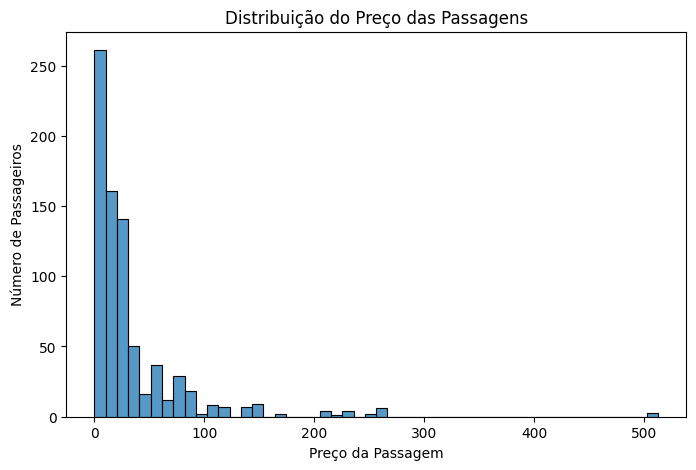

In [76]:
# Distribuição do preço das passagens entre os passageiros
plt.figure(figsize=(8,5))
sns.histplot(data=df_titanic, x='Fare', bins=50)
plt.title('Distribuição do Preço das Passagens')
plt.xlabel('Preço da Passagem')
plt.ylabel('Número de Passageiros')
plt.show()

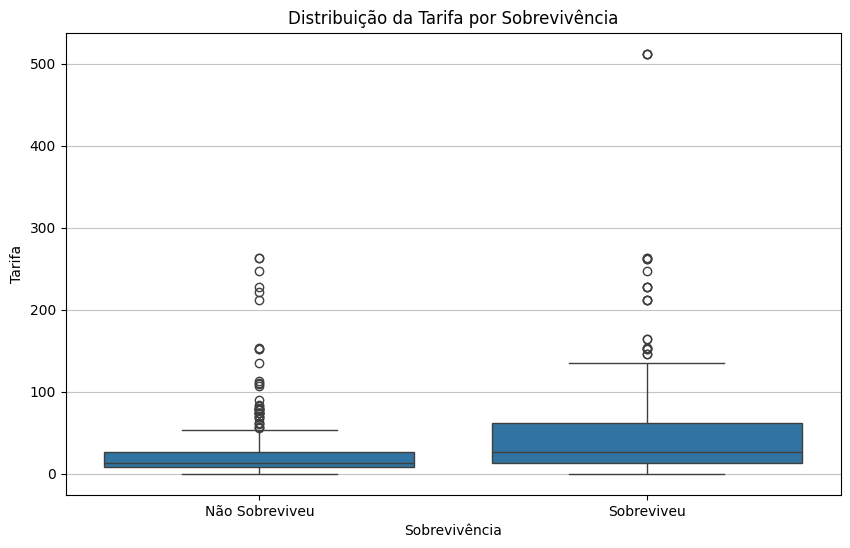

In [77]:
# Distribuição da Tarifa por Sobrevivência
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=df_titanic)
plt.title('Distribuição da Tarifa por Sobrevivência')
plt.xlabel('Sobrevivência')
plt.ylabel('Tarifa')
plt.xticks([0, 1], ['Não Sobreviveu', 'Sobreviveu'])
plt.grid(axis='y', alpha=0.75)
plt.show()

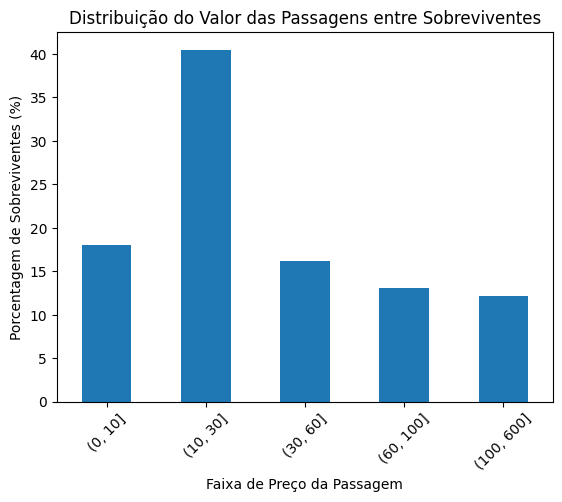

In [78]:
# Distribuição do valor das passagens por sobrevivência
bins = [0,10,30,60,100,600]
sobreviventes = df_titanic[df_titanic['Survived'] == 1]
porcentagem = pd.cut(sobreviventes['Fare'], bins=bins).value_counts(normalize=True) * 100
porcentagem.sort_index().plot(kind='bar')
plt.title('Distribuição do Valor das Passagens entre Sobreviventes')
plt.xlabel('Faixa de Preço da Passagem')
plt.xticks(rotation=45)
plt.ylabel('Porcentagem de Sobreviventes (%)')
plt.show()

In [79]:
#Média da Tarifa entre Sobreviventes
media_tarifa_sobreviventes = df_titanic[df_titanic['Survived'] == 1]['Fare'].mean()
print(f"Média da tarifa paga pelos sobreviventes: R$ {media_tarifa_sobreviventes:.2f}")

Média da tarifa paga pelos sobreviventes: R$ 50.19


Passageiros que pagaram valores mais altos pelas passagens tendem a apresentar uma taxa de sobrevivência maior. Isso sugere que o preço da passagem, que está frequentemente associado à classe social do passageiro, pode ter influenciado as chances de sobrevivência.

Esse padrão reforça os resultados observados anteriormente na análise por classe do passageiro (Pclass), indicando que passageiros de classes mais altas possivelmente tiveram maior acesso aos recursos de evacuação e melhores condições durante o resgate.

Entretanto, também é possível observar uma grande variação nos valores das passagens, indicando que o preço da passagem não foi o único fator determinante para a sobrevivência.

## Sobrevivência por Porto de Embarque

Outro fator que pode estar relacionado às chances de sobrevivência dos passageiros é o porto de embarque. A variável Embarked indica o local onde cada passageiro embarcou no Titanic.

Os três portos presentes no DataFrame são:

C – Cherbourg (França)

Q – Queenstown (Irlanda)

S – Southampton (Inglaterra)

Analisar a relação entre porto de embarque e sobrevivência pode ajudar a identificar possíveis padrões associados ao perfil dos passageiros que embarcaram em cada local.

In [80]:
# Contagem de passageiros por porto de embarque
df_titanic['Embarked'].value_counts()

,count
Embarked,
S,567
C,155
Q,58


In [81]:
# Taxa de sobrevivência por porto de embarque
df_titanic.groupby('Embarked',observed=True)['Survived'].mean()*100

,Survived
Embarked,
C,58.064516
Q,34.482759
S,37.389771


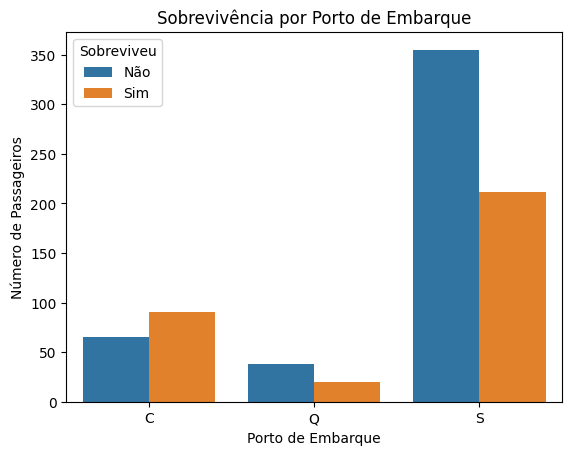

In [82]:
# Sobrevivência por porto de embarque
sns.countplot(x='Embarked', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Porto de Embarque')
plt.xlabel('Porto de Embarque')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

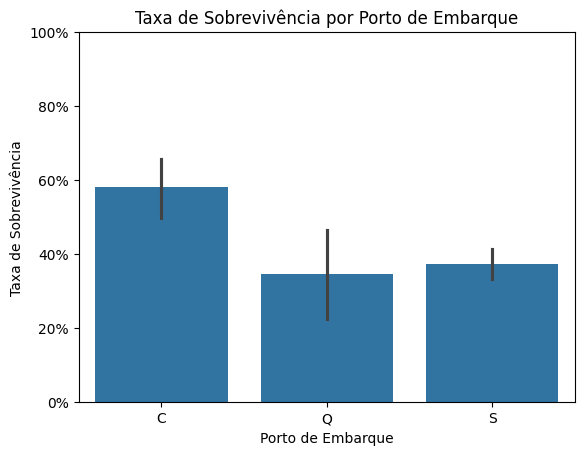

In [83]:
# Taxa de sobrevivência por porto de embarque
sns.barplot(x='Embarked', y='Survived', data=df_titanic)
plt.title('Taxa de Sobrevivência por Porto de Embarque')
plt.xlabel('Porto de Embarque')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

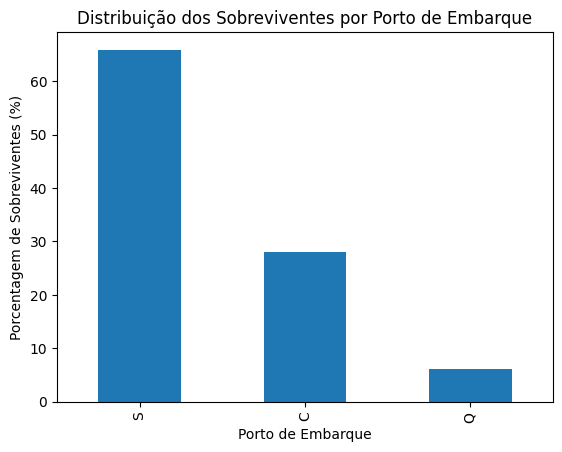

In [84]:
# Distribuição dos sobreviventes por porto de embarque
sobreviventes = df_titanic[df_titanic['Survived'] == 1]
porcentagem = sobreviventes['Embarked'].value_counts(normalize=True) * 100
porcentagem.plot(kind='bar')
plt.title('Distribuição dos Sobreviventes por Porto de Embarque')
plt.xlabel('Porto de Embarque')
plt.ylabel('Porcentagem de Sobreviventes (%)')
plt.show()

Observa-se diferenças nas taxas de sobrevivência entre os passageiros que embarcaram em diferentes portos. Passageiros que embarcaram em Cherbourg apresentam uma taxa de sobrevivência relativamente maior em comparação com os demais portos.

Essa diferença pode estar relacionada ao perfil socioeconômico dos passageiros, já que uma proporção maior de passageiros da primeira classe embarcou em Cherbourg, enquanto muitos passageiros da terceira classe embarcaram em Southampton (que tiveram menor taxa de sobrevivência).

Esses resultados sugerem que o porto de embarque pode estar indiretamente relacionado à sobrevivência, principalmente por estar associado à classe social e perfil dos passageiros.

# 7.Análises Cruzadas/Relações entre Variáveis

Ao analisar relações entre diferentes variáveis, podemos identificar padrões mais complexos e interações entre fatores que podem ter influenciado a sobrevivência dos passageiros.

## Sobrevivência por Gênero e Classe Social

Essa combinação é particularmente interessante, pois permite observar se a diferença de sobrevivência entre homens e mulheres também varia de acordo com a classe do passageiro.

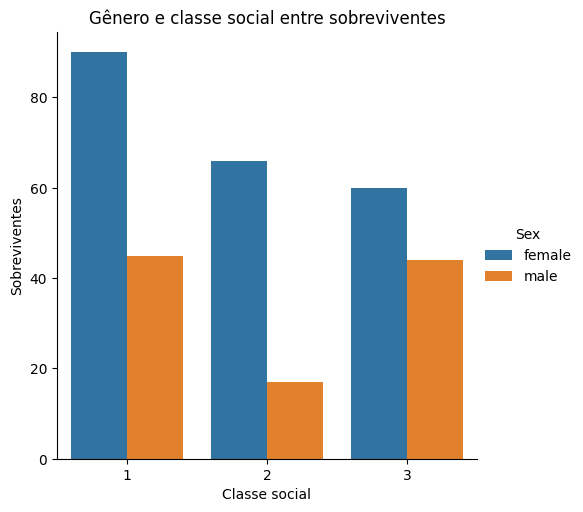

In [85]:
# Contagem de sobreviventes por gênero e classe social
sns.catplot(x='Pclass', hue='Sex', kind='count', data=df_titanic[df_titanic['Survived'] == 1])
plt.title('Gênero e classe social entre sobreviventes')
plt.xlabel('Classe social')
plt.ylabel('Sobreviventes')
plt.show()

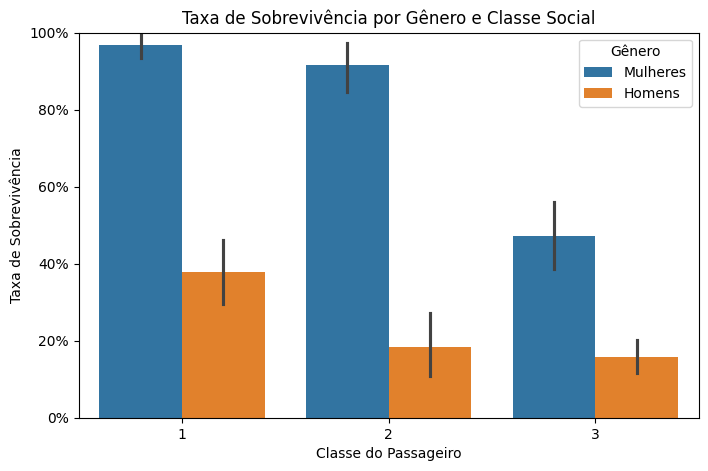

In [86]:
# Taxa de sobrevivência por gênero e classe social
plt.figure(figsize=(8,5))
ax = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df_titanic)
plt.title('Taxa de Sobrevivência por Gênero e Classe Social')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
handles, labels = ax.get_legend_handles_labels()
labels = ['Homens' if l=='male' else 'Mulheres' for l in labels]
ax.legend(handles, labels, title='Gênero')
plt.show()

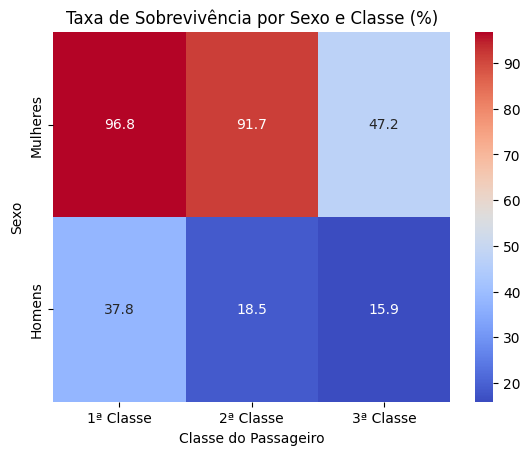

In [87]:
# Heatmap de sobrevivência por sexo e classe
tabela = df_titanic.pivot_table(values='Survived', index='Sex', columns='Pclass', observed=True)*100
tabela.index = ['Mulheres', 'Homens']
tabela.columns = ['1ª Classe', '2ª Classe', '3ª Classe']
sns.heatmap(tabela, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Taxa de Sobrevivência por Sexo e Classe (%)')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Sexo')
plt.show()


A análise mostra que mulheres apresentaram taxas de sobrevivência maiores em todas as classes sociais. No entanto, passageiros da primeira classe tiveram maiores chances de sobreviver em comparação com as classes mais baixas.

Entre os homens, observa-se uma taxa de sobrevivência significativamente menor, especialmente entre os passageiros da terceira classe.

## Sobrevivência por Idade/Faixa Etária e Gênero

Nesta etapa será analisada a relação entre idade/faixa etária, gênero e sobrevivência. O objetivo é verificar se existem diferenças na distribuição de idades entre homens e mulheres que sobreviveram ao desastre.

In [88]:
#Taxa Sobrevivência por faixa etária e gênero
taxa_sobrevivencia_idade_sexo = df_titanic.groupby(['Sex', 'FaixaEtaria'], observed=False)['Survived'].mean() * 100
print("Taxa de sobrevivência por faixa etária e gênero:")
display(taxa_sobrevivencia_idade_sexo)

Taxa de sobrevivência por faixa etária e gênero:


Sex     FaixaEtaria
female  Crianca         58.064516
        Adolescente     75.000000
        JovemAdulto     75.324675
        Adulto          76.470588
        Idoso          100.000000
male    Crianca         56.756757
        Adolescente      9.677419
        JovemAdulto     20.071685
        Adulto          19.512195
        Idoso           11.111111
Name: Survived, dtype: float64

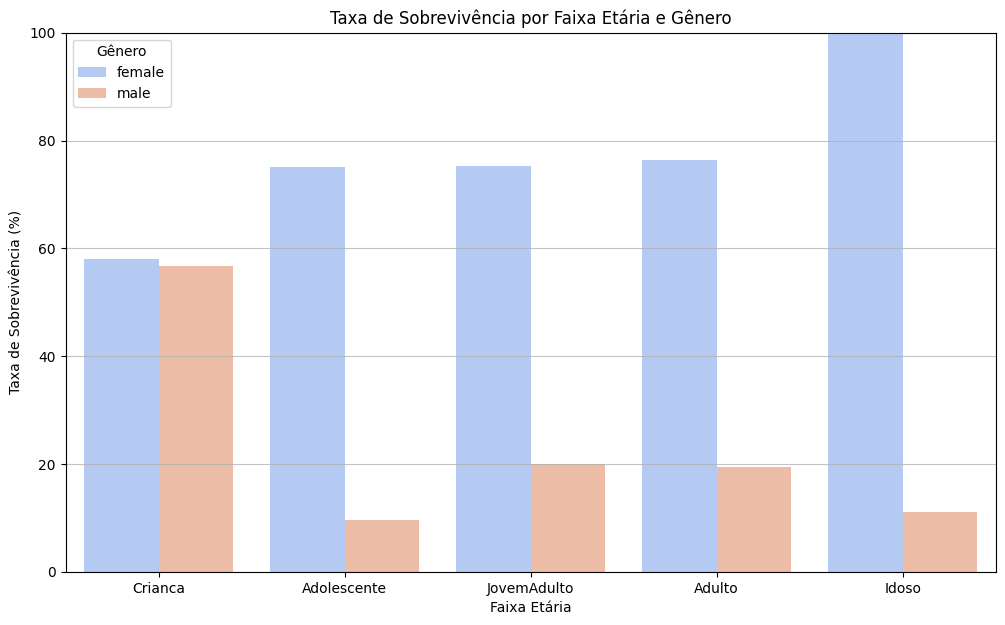

In [89]:
# Visualização Sobrevivência por faixa etária e gênero
plt.figure(figsize=(12, 7))
sns.barplot(x='FaixaEtaria', y='Survived', hue='Sex', data=taxa_sobrevivencia_idade_sexo.reset_index(), palette='coolwarm')
plt.title('Taxa de Sobrevivência por Faixa Etária e Gênero')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.75)
plt.legend(title='Gênero')
plt.show()

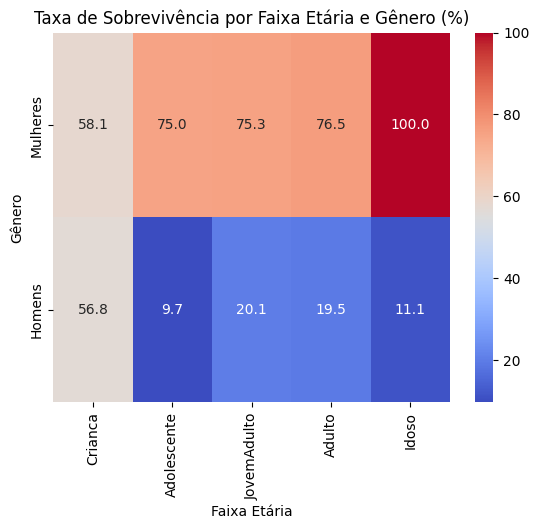

In [90]:
# Heatmap de sobrevivência por faixa etária e gênero
tabela = df_titanic.pivot_table(values='Survived', index='Sex', columns='FaixaEtaria', observed=True) * 100
tabela.index = tabela.index.map({'male':'Homens', 'female':'Mulheres'})
sns.heatmap(tabela, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Taxa de Sobrevivência por Faixa Etária e Gênero (%)')
plt.xlabel('Faixa Etária')
plt.ylabel('Gênero')
plt.show()

Observamos como a idade dos passageiros se distribui entre homens e mulheres que sobreviveram ou não ao desastre. As visualizações sugerem que crianças e mulheres tiveram maiores chances de sobrevivência, reforçando a ideia de que houve prioridade para estes grupos durante o resgate.

## Sobrevivência por Classe Social e Porto de Embarque

Nesta análise será investigada a relação entre classe social, porto de embarque e sobrevivência. Como diferentes portos podem ter embarcado passageiros com perfis distintos, essa análise ajuda a compreender se existe alguma associação entre essas variáveis.

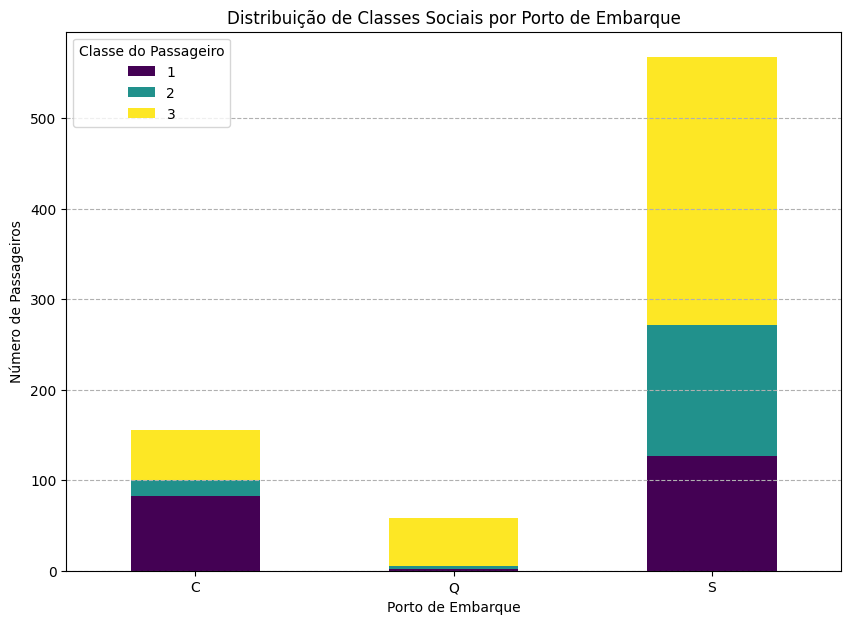

In [91]:
# Distribuição da classe social do passageiro por porto de embarque
distribuicao_classes_por_porto = pd.crosstab(df_titanic['Embarked'], df_titanic['Pclass'])
distribuicao_classes_por_porto.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')
plt.title('Distribuição de Classes Sociais por Porto de Embarque')
plt.xlabel('Porto de Embarque')
plt.ylabel('Número de Passageiros')
plt.xticks(rotation=0)
plt.legend(title='Classe do Passageiro')
plt.grid(axis='y', linestyle='--')
plt.show()

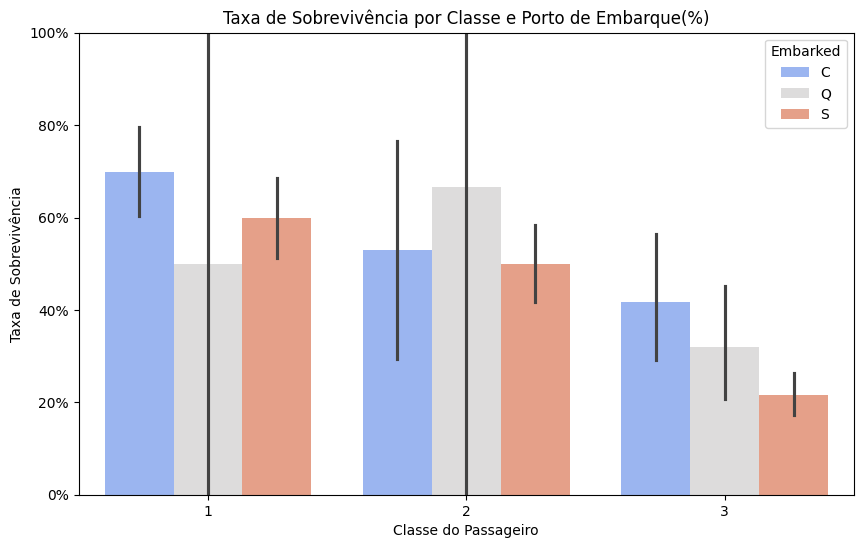

In [92]:
# Taxa de Sobrevivência por Classe e Porto de Embarque
plt.figure(figsize=(10,6))
sns.barplot(x='Pclass', y='Survived', hue='Embarked', data=df_titanic, palette='coolwarm')
plt.title('Taxa de Sobrevivência por Classe e Porto de Embarque(%)')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

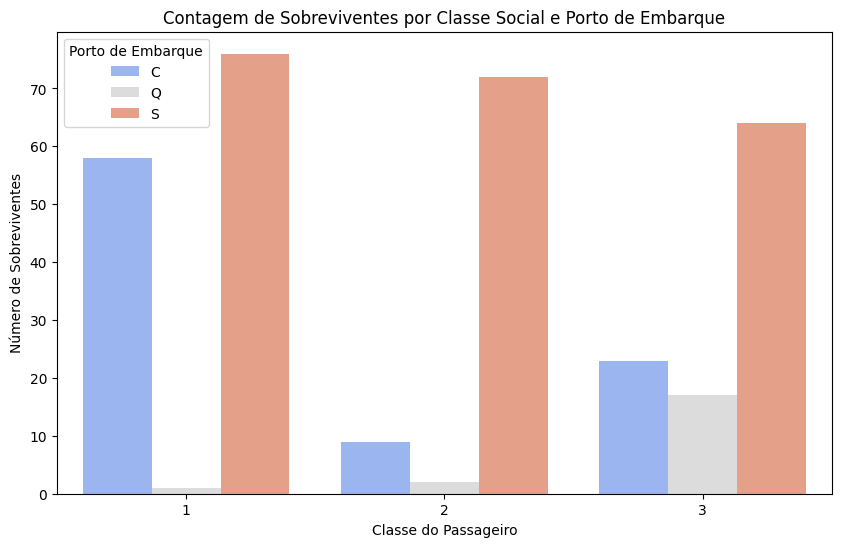

In [93]:
# Contagem de sobreviventes por classe social e porto de embarque
plt.figure(figsize=(10,6))
sns.countplot(x='Pclass', hue='Embarked', data=df_titanic[df_titanic['Survived'] == 1], palette='coolwarm')
plt.title('Contagem de Sobreviventes por Classe Social e Porto de Embarque')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Número de Sobreviventes')
plt.legend(title='Porto de Embarque')
plt.show()

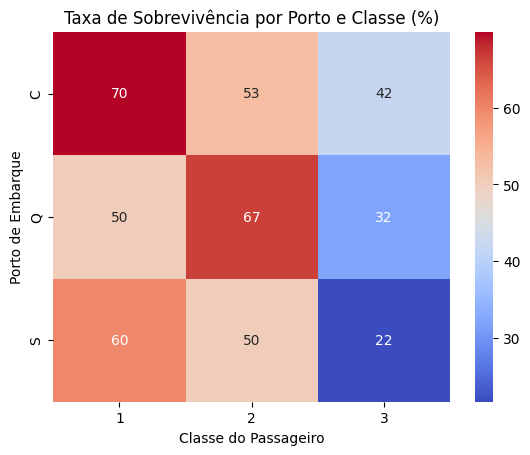

In [94]:
# Heatmap de sobrevivência por classe e porto
tabela = df_titanic.pivot_table(values='Survived', index='Embarked', columns='Pclass', observed=True)*100
sns.heatmap(tabela, annot=True, cmap='coolwarm')
plt.title('Taxa de Sobrevivência por Porto e Classe (%)')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Porto de Embarque')
plt.show()

Percebemos como a sobrevivência varia entre diferentes classes sociais dentro de cada porto de embarque. Nota-se que passageiros da primeira classe apresentaram maiores taxas de sobrevivência em praticamente todos os portos, enquanto passageiros da terceira classe apresentaram as menores chances de sobreviver.

# 8.Análise de Correlação

## Matriz de Correlação entre Variáveis Numéricas

Além das análises visuais, também é útil analisar a correlação entre variáveis numéricas. A matriz de correlação permite identificar relações entre diferentes variáveis, indicando se elas apresentam associação positiva, negativa ou pouca relação entre si.

In [95]:
# Variáveis numéricas relevantes
colunas = ['Survived','Age', 'SibSp', 'Parch','Fare','TamanhoFamilia','PassSozinho']
# Matriz de correlação
matriz_correlacao = df_titanic[colunas].corr()
print("Matriz de Correlação:")
display(matriz_correlacao)


Matriz de Correlação:


,Survived,Age,SibSp,Parch,Fare,TamanhoFamilia,PassSozinho
Survived,1.000000,-0.077843,-0.037597,0.069669,0.246669,0.013996,-0.175864
Age,-0.077843,1.000000,-0.278655,-0.182174,0.092566,-0.281656,0.189145
SibSp,-0.037597,-0.278655,1.000000,0.380596,0.134127,0.860061,-0.608756
Parch,0.069669,-0.182174,0.380596,1.000000,0.191055,0.799131,-0.570338
Fare,0.246669,0.092566,0.134127,0.191055,1.000000,0.192601,-0.245279
TamanhoFamilia,0.013996,-0.281656,0.860061,0.799131,0.192601,1.000000,-0.710404
PassSozinho,-0.175864,0.189145,-0.608756,-0.570338,-0.245279,-0.710404,1.000000


A heatmap da matriz de correlação apresenta a relação entre as variáveis numéricas do conjunto de dados do Titanic.

A correlação varia de -1 a 1, onde:

- Valores próximos de 1 indicam correlação positiva forte (as variáveis aumentam juntas).

- Valores próximos de -1 indicam correlação negativa forte (quando uma aumenta, a outra diminui).

- Valores próximos de 0 indicam relação fraca ou inexistente.

**Nesta visualização, cores mais vermelhas indicam correlação positiva, enquanto cores mais azuis indicam correlação negativa.**


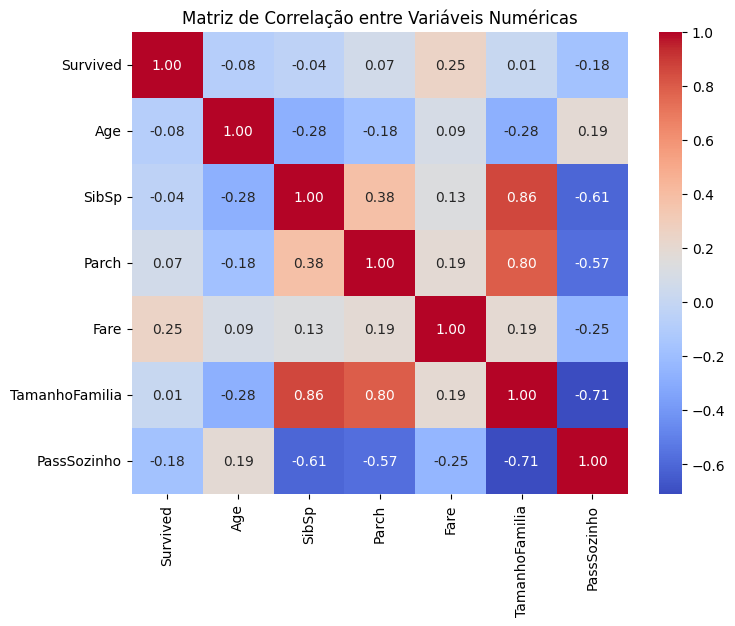

In [96]:
# Heatmap matriz de correlação entre variáveis numéricas
plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

**Relação das variáveis com a sobrevivência (Survived):**

- **Fare (0.25):** apresenta uma correlação positiva moderada. Passageiros que pagaram tarifas mais altas tinham maior probabilidade de sobreviver. Isso pode estar relacionado ao fato de passageiros de classes mais altas terem tido maior acesso aos botes salva-vidas.

- **PassSozinho (-0.18):** apresenta correlação negativa. Passageiros que viajavam sozinhos tiveram uma probabilidade um pouco menor de sobreviver.

- **Age (-0.08) e SibSp (-0.04):** possuem correlações muito fracas com a sobrevivência, indicando pouca influência direta.

- **Parch (0.07):** também mostra uma relação muito fraca com a sobrevivência.

De modo geral, nenhuma variável numérica apresenta correlação muito forte com a sobrevivência, indicando que outros fatores importantes (como sexo ou classe social) podem ter maior influência.

**Relações entre as variáveis explicativas:**

- **SibSp e TamanhoFamilia (0.86):** apresentam forte correlação positiva, o que é esperado, pois o número de irmãos/cônjuges contribui diretamente para o tamanho da família.

- **Parch e TamanhoFamilia (0.80):** também mostram forte correlação positiva, já que pais e filhos a bordo fazem parte da composição familiar.

- **PassSozinho e TamanhoFamilia (-0.71):** apresentam forte correlação negativa, pois passageiros que viajavam sozinhos naturalmente possuem tamanho de família igual a zero.

- **SibSp e PassSozinho (-0.61) e Parch e PassSozinho (-0.57):** também mostram correlações negativas relevantes, reforçando a mesma lógica.

**Conclusão**

A matriz de correlação indica que as variáveis relacionadas ao contexto familiar possuem forte relação entre si, enquanto as variáveis numéricas analisadas apresentam baixa correlação direta com a sobrevivência. Entre elas, Fare foi a que apresentou a maior associação positiva com a sobrevivência, sugerindo que passageiros que pagaram tarifas mais altas tiveram maior chance de sobreviver.

# 9.Principais Insights da Análise

Ao longo deste notebook foram realizadas Análise Estatística, Análise Exploratória dos dados e Análise de Correlação do DataSet do Titanic, com o objetivo de identificar fatores que podem ter influenciado as chances de sobrevivência dos passageiros. A partir dessas análises, foi possível identificar alguns padrões importantes.

## Influência do gênero

Um dos fatores mais relevantes observados foi o gênero dos passageiros. Passageiras apresentaram uma taxa de sobrevivência significativamente maior em comparação com passageiros. Esse resultado está alinhado com os relatos históricos de que mulheres e crianças tiveram prioridade no acesso aos botes salva-vidas.

## Influência da classe social

A classe da passagem também mostrou forte relação com a sobrevivência. Passageiros da primeira classe tiveram maiores chances de sobreviver, enquanto passageiros da terceira classe apresentaram as menores taxas de sobrevivência. Esse padrão pode estar relacionado à localização das cabines e ao acesso aos botes salva-vidas.

## Influência da idade

A análise da idade indicou que crianças apresentaram uma taxa de sobrevivência relativamente maior em comparação com adultos. Isso reforça a hipótese de que houve prioridade para mulheres e crianças durante o resgate.

## Influência do preço da passagem

Passageiros que pagaram valores mais altos pelas passagens também apresentaram maiores taxas de sobrevivência. Como o preço da passagem está geralmente associado à classe social, esse fator reforça a relação observada anteriormente entre classe social e sobrevivência.

## Influência do tamanho da família

O tamanho da família a bordo também parece ter influenciado as chances de sobrevivência. Passageiros que viajavam sozinhos ou em famílias muito grandes apresentaram menores taxas de sobrevivência, enquanto passageiros em famílias pequenas tiveram resultados um pouco melhores, possivelmente devido ao apoio entre familiares e/ou à organização durante a evacuação.

## Influência do porto de embarque

Diferenças também foram observadas entre os passageiros que embarcaram em diferentes portos. Passageiros que embarcaram em Cherbourg apresentaram uma taxa de sobrevivência maior, possivelmente devido à maior presença de passageiros de classe mais alta nesse porto.

## Conclusão geral

De forma geral, a análise sugere que a sobrevivência no Titanic não foi aleatória. Esta foi fortemente influenciada por uma combinação de fatores sociais e demográficos.

A análise mostra que os fatores mais importantes para a sobrevivência foram gênero, classe social e idade. Mulheres e passageiros da primeira classe tiveram maior probabilidade de sobreviver, enquanto homens da terceira classe apresentaram as menores taxas.

Esses resultados demonstram como a Análise Exploratória de Dados pode ajudar a identificar padrões importantes em conjuntos de dados históricos, permitindo compreender melhor os fatores que podem ter contribuído para determinados eventos. Desta forma, podemos auxiliar a criação de ações e protocolos a fim de diminuir os danos e prejuízos, prevenir e antecipar futuras tragédias.

